In [127]:
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier, plot_importance
import seaborn as sns
import matplotlib.pyplot as plt
import shap
# must be set so that figures do not get cut off
plt.rcParams['figure.autolayout'] = True

In [1]:
# import drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Define Folder Paths

In [123]:
# folder path to ML data
ML_data_folder_path = '/content/drive/My Drive/capstone_data/ml_data_automation_test/'

# folder path to save classification reports
classification_report_folder = '/content/drive/My Drive/capstone_data/ML_results/classification_reports/'

# folder path to save confusion matrix figures
confusion_matrix_folder = '/content/drive/My Drive/capstone_data/ML_results/confusion_matrices/'

# folder path to store feature importance figures
feature_importance_folder = '/content/drive/My Drive/capstone_data/ML_results/feature_importance_plots/'

# probablistic forecast details path
forecast_details_folder = '/content/drive/My Drive/capstone_data/ML_results/probablistic_forecast_details/'

# folder path to save trained models
model_folder = '/content/drive/My Drive/capstone_data/ML_results/trained_models/'

# folder path to shap feature importance figures
shap_feature_importance_folder = '/content/drive/My Drive/capstone_data/ML_results/shap_feature_importance_plots/'

# normalize all folder paths
ML_data_folder_path = os.path.normpath(ML_data_folder_path)
classification_report_folder = os.path.normpath(classification_report_folder)
confusion_matrix_folder = os.path.normpath(confusion_matrix_folder)
feature_importance_folder = os.path.normpath(feature_importance_folder)
forecast_details_folder = os.path.normpath(forecast_details_folder)
model_folder = os.path.normpath(model_folder)
shap_feature_importance_folder = os.path.normpath(shap_feature_importance_folder)

# Current XGBoost Model:
- Evaluation Metric: Multi-Class Log Loss (mlogloss)
- No Cross Validation
- No PCA
- No Hyperparameter Tuning
- No Early Stopping for Overfitting
- Weight Feature Importance

# Seasonal Prediction ML Automation

- for every region and every season, train the same xgboost model, save all the results and save the model

- Data are seasonal, with each season labeled with its respective seasonal tercile

1993 MAM has 1993 MAM's tercile

In [126]:
# Ensure the output directories exist
os.makedirs(confusion_matrix_folder, exist_ok=True)
os.makedirs(feature_importance_folder, exist_ok=True)
os.makedirs(classification_report_folder, exist_ok=True)
os.makedirs(forecast_details_folder, exist_ok=True)
os.makedirs(model_folder, exist_ok=True)

# Loop over all CSVs in ML data folder
for filename in os.listdir(ML_data_folder_path):
    if filename.endswith('_seasonal.csv'):
        # Load the CSV
        df = pd.read_csv(os.path.join(ML_data_folder_path, filename))

        # Extract region name and season from file path
        region_name = '_'.join(filename.split('_')[0:-4])
        season = filename.split('_')[-4]

        # Status
        print(f"Currently Processing {region_name} Region, {season} Season")

        # Drop relevant columns based on the data if they are there
        if 'precip' in df.columns:
            df.drop(columns=['precip'], inplace=True)
        if 'region' in df.columns:
            df.drop(columns=['region'], inplace=True)
        if 'season' in df.columns:
            df.drop(columns=['season'], inplace=True)

        # Choose train and test years manually
        train_years = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
                       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
                       2014, 2015, 2016, 2017, 2018, 2019, 2020]

        test_years = [2021, 2022, 2023, 2024]

        # Manual split
        train_df = df[df['year'].isin(train_years)]
        test_df = df[df['year'].isin(test_years)]

        # Separate Features and labels
        X_train = train_df.drop(columns=['year', 'tercile'])
        X_test = test_df.drop(columns=['year', 'tercile'])
        y_train = train_df['tercile']
        y_test = test_df['tercile']

        # Encode labels (an: 1 0 0, bn: 0 0 1, n: 0 1 0)
        le = LabelEncoder()
        y_train_enc = le.fit_transform(y_train)
        y_test_enc = le.transform(y_test)

        # Define model
        model = XGBClassifier(eval_metric='mlogloss')

        # Train the model on Training data and training labels
        model.fit(X_train, y_train_enc)

        # Predict classes
        y_pred = model.predict(X_test)

        # Predict probabilities for each class
        y_proba = model.predict_proba(X_test)

        # Save the model
        model_save_path = os.path.join(model_folder, f"{region_name}_{season}_seasonal_model.json")
        model.save_model(model_save_path)
        print(f"Model saved to {model_save_path}")

        # Save the classification report as a text file
        classification_report_path = os.path.join(classification_report_folder, f"{region_name}_{season}_seasonal_model_classification_report.txt")
        with open(classification_report_path, 'w') as f:
            f.write(f"{region_name} {season} Long Lead Seasonal Model\n=== Classification Report ===\n")
            f.write(classification_report(
                y_test_enc,
                y_pred,
                labels=[0, 1, 2],  # Ensure all label indices are present
                target_names=le.classes_,
                zero_division=0  # Handle division by zero (i.e N was not in test data)
            ))
        print(f"Classification report saved to {classification_report_path}")

        # Confusion matrix
        conf_mat = confusion_matrix(y_test_enc, y_pred, labels=[0, 1, 2])
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_mat, annot=True, fmt='d',
                    xticklabels=le.classes_, yticklabels=le.classes_,
                    cmap='Blues')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'{region_name} {season} \nLong Lead Seasonal Model\nConfusion Matrix')

        # Save the confusion matrix
        conf_matrix_file = os.path.join(confusion_matrix_folder, f'{region_name}_{season}_seasonal_model_confusion_matrix.png')
        plt.savefig(conf_matrix_file, dpi=300)
        plt.close()
        print(f"Confusion matrix saved to {conf_matrix_file}")

        # Feature importance plot
        plt.figure(figsize=(20, 12))
        plot_importance(model, max_num_features=20, importance_type='weight', height=0.5)
        plt.title(f'{region_name} {season} \nLong Lead Seasonal Model \nTop 20 Feature Importances')

        # Save the feature importance plot
        feature_importance_file = os.path.join(feature_importance_folder, f'{region_name}_{season}_seasonal_model_feature_importance.png')
        plt.savefig(feature_importance_file, dpi=300)
        plt.close()
        print(f"Feature importance plot saved to {feature_importance_file}")

        # Create explainer
        explainer = shap.Explainer(model, X_train)

        # Compute SHAP values
        shap_values = explainer(X_test)

        # get the class names from the model's encoder
        class_names = le.classes_

        # Use matplotlib-compatible SHAP summary bar plot
        plt.figure(figsize=(20, 12))
        shap.summary_plot(shap_values.values, X_test, plot_type="bar", class_names=class_names, show=False) # use class names list to label shap plot
        plt.title(f'{region_name} {season} \nLong Lead Seasonal Model \nTop 20 SHAP Feature Importances')

        plt.savefig(os.path.join(shap_feature_importance_folder, f'{region_name}_{season}_seasonal_model_shap_feature_importance.png'), dpi=300)
        plt.close()
        print(f"SHAP feature importance plot saved to {shap_feature_importance_folder}/{region_name}_{season}_seasonal_model_shap_feature_importance.png")

        # Probabilistic forecast details

        # Reset index to ensure alignment
        test_info = test_df[['year']].reset_index(drop=True)  # Only 'year' for seasonal data
        proba_df = pd.DataFrame(y_proba, columns=[f"proba_{cls}" for cls in le.classes_])

        # Concatenate year and predicted probabilities
        results_df = pd.concat([test_info, proba_df], axis=1)

        # Add predicted and true class labels
        results_df['true_label'] = le.inverse_transform(y_test_enc)
        results_df['predicted_label'] = le.inverse_transform(y_pred)

        # Save the results
        forecast_details_file = os.path.join(forecast_details_folder, f"{region_name}_{season}_seasonal_model_probabilistic_forecast_details.txt")
        with open(forecast_details_file, 'w') as f:
            f.write(f"{region_name} {season} Long Lead Seasonal Model\n=== Seasonal Predictions with Probabilities ===\n")
            f.write(results_df.to_string(index=False))
        print(f"Probabilistic forecast details saved to {forecast_details_file}")


Currently Processing eastern_east_africa Region, OND Season
Model saved to /content/drive/My Drive/capstone_data/ML_results/trained_models/eastern_east_africa_OND_seasonal_model.json
Classification report saved to /content/drive/My Drive/capstone_data/ML_results/classification_reports/eastern_east_africa_OND_seasonal_model_classification_report.txt
Confusion matrix saved to /content/drive/My Drive/capstone_data/ML_results/confusion_matrices/eastern_east_africa_OND_seasonal_model_confusion_matrix.png
Feature importance plot saved to /content/drive/My Drive/capstone_data/ML_results/feature_importance_plots/eastern_east_africa_OND_seasonal_model_feature_importance.png
SHAP feature importance plot saved to /content/drive/My Drive/capstone_data/ML_results/shap_feature_importance_plots/eastern_east_africa_OND_seasonal_model_shap_feature_importance.png
Probabilistic forecast details saved to /content/drive/My Drive/capstone_data/ML_results/probablistic_forecast_details/eastern_east_africa_OND

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

...

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

# Monthly Prediction
- Data are monthly, with monthly tercile assignment
- For example, month 3 will have month 3's tercile, and so on and so forth.

In [54]:
# Load the CSV
df = pd.read_csv("/content/drive/My Drive/capstone_data/ml_data_automation_test/eastern_east_africa_MAM_ml_data_monthly.csv")

# drop precip
df = df.drop(columns=['precip', 'region'])

# Choose years manually
train_years = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
               2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
               2014, 2015, 2016, 2017, 2018, 2019, 2020]

test_years = [2021, 2022, 2023, 2024]

# Manual split
train_df = df[df['year'].isin(train_years)]
test_df = df[df['year'].isin(test_years)]

# Separate Features and labels
X_train = train_df.drop(columns=['year', 'tercile'])
X_test = test_df.drop(columns=['year', 'tercile'])
y_train = train_df['tercile']
y_test = test_df['tercile']

# Encode labels (an: 1 0 0, bn: 0 0 1, n: 0 1 0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [55]:
# Define model
model = XGBClassifier(eval_metric='mlogloss')

# Train the model on Training data and training labels
model.fit(X_train, y_train_enc)

# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities for each class
y_proba = model.predict_proba(X_test)

In [56]:
# Classification report
print("=== Classification Report ===")
print(classification_report(
    y_test_enc,
    y_pred,
    labels=[0, 1, 2],  # Ensure all label indices are present
    target_names=le.classes_,
    zero_division=0  # Handle division by zero
))

=== Classification Report ===
              precision    recall  f1-score   support

          an       0.22      0.67      0.33         3
          bn       0.50      0.25      0.33         4
           n       0.00      0.00      0.00         5

    accuracy                           0.25        12
   macro avg       0.24      0.31      0.22        12
weighted avg       0.22      0.25      0.19        12



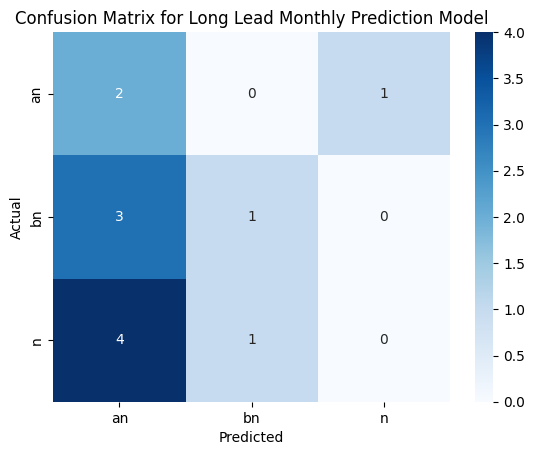

In [57]:
# Confusion matrix
conf_mat = confusion_matrix(y_test_enc, y_pred, labels=[0, 1, 2])
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Long Lead Monthly Prediction Model')
plt.show()

# Monthly data, with seasonal terciles for each month

For example, month 3 will have MAM's tercile, and so will month 4 and 5.

In [58]:
# Load the CSV
df = pd.read_csv("/content/drive/My Drive/capstone_data/ml_data_automation_test/eastern_east_africa_MAM_ml_data_monthly_seasonal_tercile.csv")

# drop precip
df = df.drop(columns=['precip', 'region', 'season'])

# Choose years manually
train_years = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
               2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
               2014, 2015, 2016, 2017, 2018, 2019, 2020]

test_years = [2021, 2022, 2023, 2024]

# Manual split
train_df = df[df['year'].isin(train_years)]
test_df = df[df['year'].isin(test_years)]

# Separate Features and labels
X_train = train_df.drop(columns=['year', 'tercile'])
X_test = test_df.drop(columns=['year', 'tercile'])
y_train = train_df['tercile']
y_test = test_df['tercile']

# Encode labels (an: 1 0 0, bn: 0 0 1, n: 0 1 0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [59]:
# Define model
model = XGBClassifier(eval_metric='mlogloss')

# Train the model on Training data and training labels
model.fit(X_train, y_train_enc)

# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities for each class
y_proba = model.predict_proba(X_test)

In [60]:
# Classification report
print("=== Classification Report ===")
print(classification_report(
    y_test_enc,
    y_pred,
    labels=[0, 1, 2],  # Ensure all label indices are present
    target_names=le.classes_,
    zero_division=0  # Handle division by zero
))

=== Classification Report ===
              precision    recall  f1-score   support

          an       1.00      0.50      0.67         6
          bn       0.67      1.00      0.80         6
           n       0.00      0.00      0.00         0

    accuracy                           0.75        12
   macro avg       0.56      0.50      0.49        12
weighted avg       0.83      0.75      0.73        12



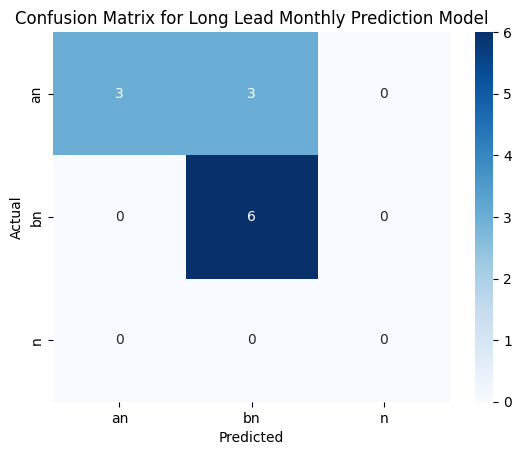

In [61]:
# Confusion matrix
conf_mat = confusion_matrix(y_test_enc, y_pred, labels=[0, 1, 2])
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Long Lead Monthly Prediction Model')
plt.show()

We see that the model never predicted N, and the test data also never had an N tercile for the years 2021-2024 for the MAM season. The model misclassified AN as BN 3 times, but correctly classified all BN years. Thus, the model may be biased towards BN observations, and this may be due to our predictors being biased towards BN.

<Figure size 1000x600 with 0 Axes>

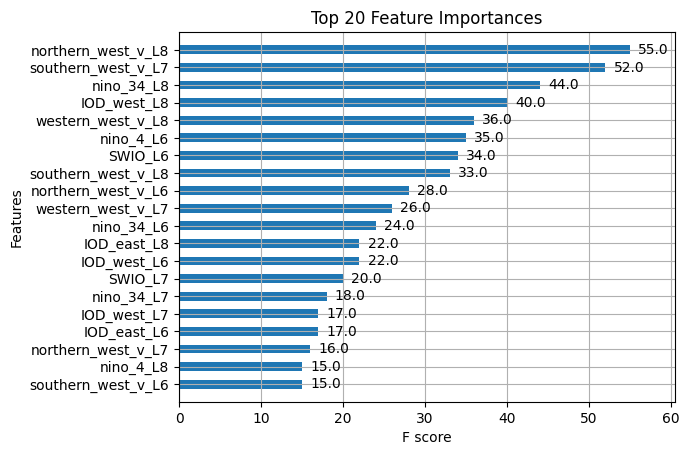

In [62]:
# Feature importance plot
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=20, importance_type='weight', height=0.5)
plt.title("Top 20 Feature Importances")
plt.show()

In [63]:
# Reset index to ensure alignment
test_info = test_df[['year', 'month']].reset_index(drop=True)
proba_df = pd.DataFrame(y_proba, columns=[f"proba_{cls}" for cls in le.classes_])

# Concatenate year, month, and predicted probabilities
results_df = pd.concat([test_info, proba_df], axis=1)

# Optional: add predicted and true class labels
results_df['true_label'] = le.inverse_transform(y_test_enc)
results_df['predicted_label'] = le.inverse_transform(y_pred)

# Print full DataFrame
print("=== EEA MAM (Monthly, Seasonal Terciles) Predictions with Probabilities ===")
print(results_df.to_string(index=False))

=== EEA MAM (Monthly, Seasonal Terciles) Predictions with Probabilities ===
 year  month  proba_an  proba_bn  proba_n true_label predicted_label
 2021      3  0.080089  0.870102 0.049810         bn              bn
 2021      4  0.223452  0.674607 0.101941         bn              bn
 2021      5  0.227821  0.612057 0.160123         bn              bn
 2022      3  0.053329  0.774942 0.171728         bn              bn
 2022      4  0.015712  0.951560 0.032729         bn              bn
 2022      5  0.023455  0.931584 0.044961         bn              bn
 2023      3  0.041858  0.840804 0.117337         an              bn
 2023      4  0.046532  0.826723 0.126746         an              bn
 2023      5  0.031248  0.839975 0.128777         an              bn
 2024      3  0.806453  0.146501 0.047046         an              an
 2024      4  0.826671  0.125103 0.048226         an              an
 2024      5  0.719901  0.111288 0.168811         an              an


In [ ]:
# Save the DataFrame to a text file
with open('results.txt', 'w') as f:
    f.write("=== EEA MAM (Monthly, Seasonal Terciles) Predictions with Probabilities ===\n")
    f.write(results_df.to_string(index=False))

Here we can see what probability of tercile category the model predicted for each year and each month in the testing data.